# AutoLSM-Swarm — sanity checks & visualizations

Quick checks for the pipeline:

1. Load and preview the labeled landslide tile dataset.
2. Browse `runs/` (rounds, agents, ledger) and pick one agent's pipeline.
3. Re-run that pipeline's `preprocess -> build_model -> train` (models aren't persisted to disk, only `pipeline.py` is, so this reproduces `driver.py`'s training step) and run inference on sample tiles.
4. Evaluate the resulting predictions (Dice/IoU) and display prediction/error maps for that group of inferences.

In [1]:
import sys
import json
import time
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

REPO_ROOT = Path.cwd()
assert (REPO_ROOT / "src").exists(), f"couldn't find src/ from {REPO_ROOT} -- run this notebook from the repo root"
sys.path.insert(0, str(REPO_ROOT / "src"))

from config import Settings
from data.dataset import load_split
from eval.infer import infer, evaluate
from eval.metrics import dice, iou
from agents.pipeline_contract import validate_module, ContractError

settings = Settings()
settings.runs_dir = Path("runs")
print(f"dataset_dir: {settings.dataset_dir}")
print(f"runs_dir:    {settings.runs_dir}")

dataset_dir: D:\Flávio Rocha USER\OneDrive\University of Twente\MSc 2025-2027\Y2Q1 Agentic and Multi Agent Systems\AutoLSM-Swarm\archive
runs_dir:    runs


## 1. Dataset

Each tile is `(128, 128, 14)`: bands B1-B12 (Sentinel-2-style, channels 0-11), slope (channel 12) and DEM (channel 13), with a binary `(128, 128)` landslide mask.

In [2]:
BAND_NAMES = [f"B{i+1}" for i in range(12)] + ["slope", "dem"]


def stretch(channel: np.ndarray) -> np.ndarray:
    """2-98 percentile contrast stretch for display only."""
    lo, hi = np.percentile(channel, [2, 98])
    if hi - lo < 1e-6:
        lo, hi = float(channel.min()), float(channel.max()) + 1e-6
    return np.clip((channel - lo) / (hi - lo), 0.0, 1.0)


def rgb_composite(tile: np.ndarray) -> np.ndarray:
    """True-color composite from bands B4(red)/B3(green)/B2(blue) -> channels 3,2,1."""
    return np.stack([stretch(tile[:, :, i]) for i in (3, 2, 1)], axis=-1)


def ndvi(tile: np.ndarray) -> np.ndarray:
    b8, b4 = tile[:, :, 7].astype(np.float64), tile[:, :, 3].astype(np.float64)
    return (b8 - b4) / (b8 + b4 + 1e-6)


def plot_dataset_samples(X: np.ndarray, y: np.ndarray, ids: list[int], n: int = 4, seed: int = 0) -> None:
    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(X), size=min(n, len(X)), replace=False)
    fig, axes = plt.subplots(len(idxs), 5, figsize=(15, 3 * len(idxs)))
    axes = np.atleast_2d(axes)
    col_titles = ["RGB (B4/B3/B2)", "NDVI", "slope", "DEM", "mask (landslide)"]
    for row, idx in enumerate(idxs):
        tile, mask = X[idx], y[idx]
        panels = [rgb_composite(tile), stretch(ndvi(tile)), stretch(tile[:, :, 12]), stretch(tile[:, :, 13]), mask]
        cmaps = [None, "RdYlGn", "terrain", "terrain", "Reds"]
        for col, (panel, cmap) in enumerate(zip(panels, cmaps)):
            ax = axes[row, col]
            ax.imshow(panel, cmap=cmap, vmin=0 if cmap == "Reds" else None, vmax=1 if cmap == "Reds" else None)
            ax.set_xticks([]); ax.set_yticks([])
            if row == 0:
                ax.set_title(col_titles[col], fontsize=10)
            if col == 0:
                ax.set_ylabel(f"tile {ids[idx]}", fontsize=9)
    fig.suptitle("Dataset preview", y=1.0)
    fig.tight_layout()
    plt.show()

train: X=(100, 128, 128, 14) y=(100, 128, 128)
val:   X=(50, 128, 128, 14) y=(50, 128, 128)
train: landslide pixels=1.856%, tiles containing landslide=70.0%
val: landslide pixels=2.532%, tiles containing landslide=82.0%


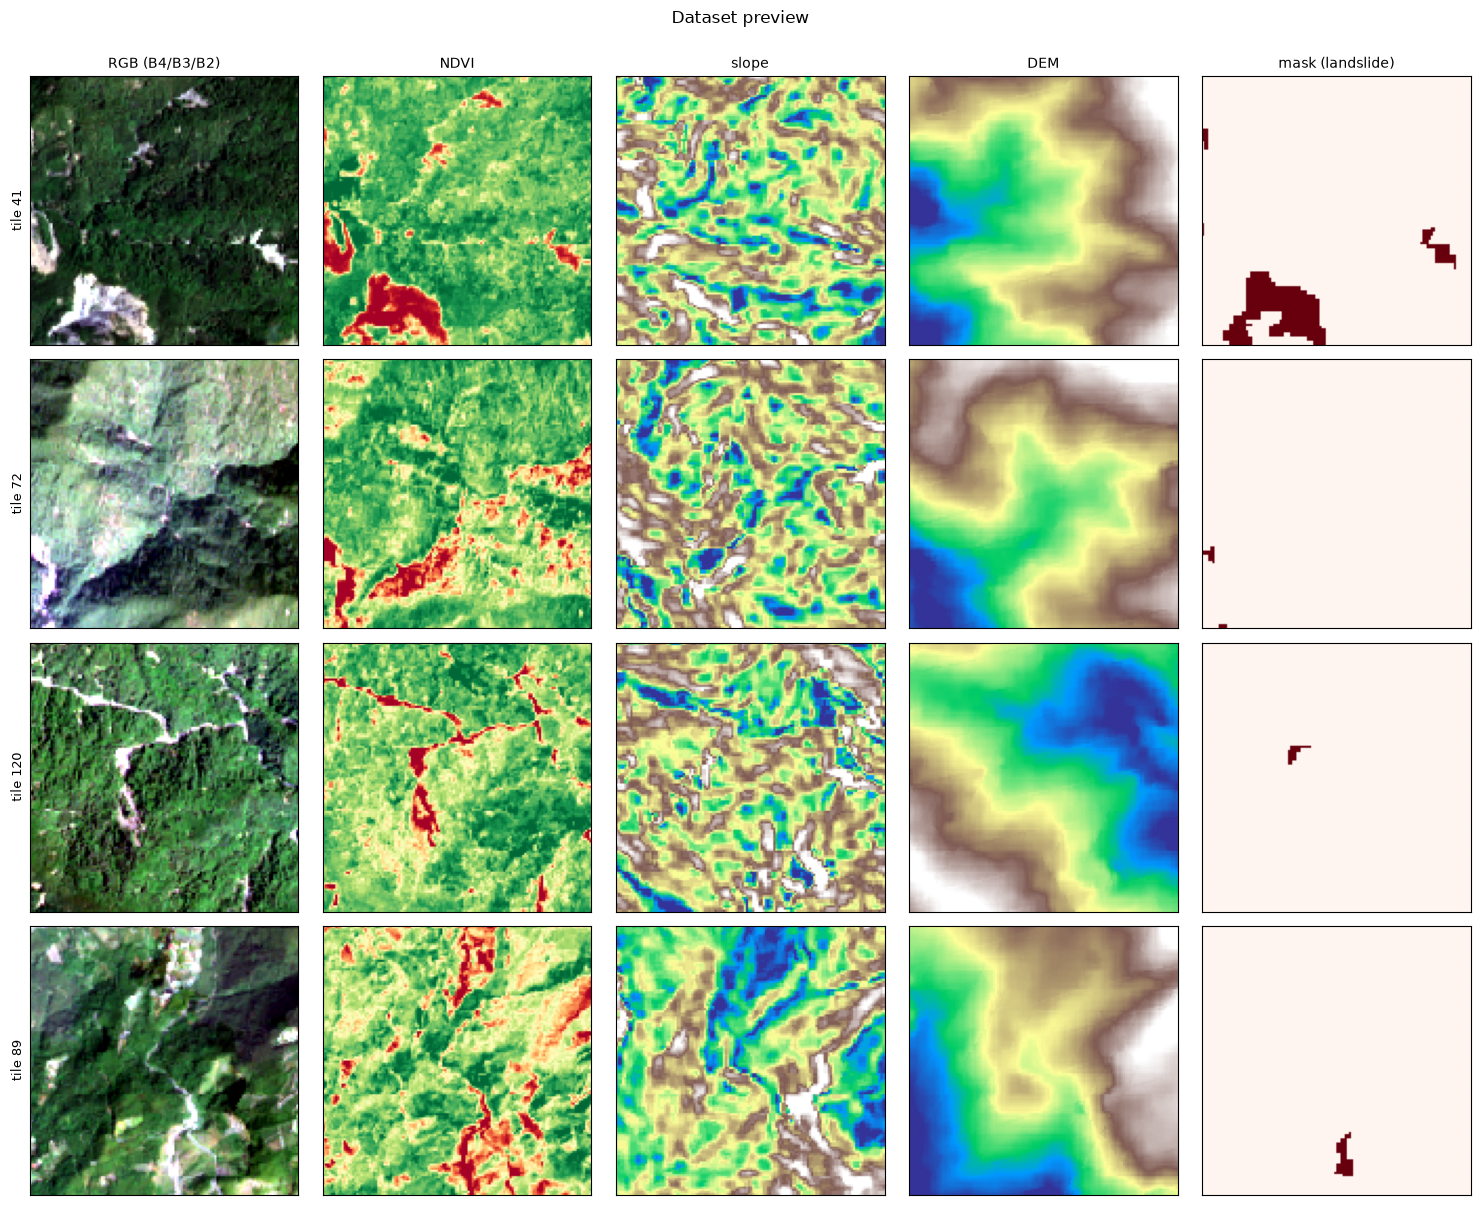

In [3]:
# Load the same fixed, seeded splits the pipeline trains/evaluates on.
# Caps default to the project settings; lower them here for a faster notebook pass.
MAX_TRAIN_TILES = settings.max_train_tiles
MAX_VAL_TILES = settings.max_val_tiles

X_train, y_train, train_ids = load_split("train", settings.dataset_dir, MAX_TRAIN_TILES)
X_val, y_val, val_ids = load_split("val", settings.dataset_dir, MAX_VAL_TILES)

print(f"train: X={X_train.shape} y={y_train.shape}")
print(f"val:   X={X_val.shape} y={y_val.shape}")
for name, y in [("train", y_train), ("val", y_val)]:
    pos_frac = y.mean()
    tiles_with_landslide = (y.reshape(len(y), -1).sum(axis=1) > 0).mean()
    print(f"{name}: landslide pixels={pos_frac:.3%}, tiles containing landslide={tiles_with_landslide:.1%}")

plot_dataset_samples(X_train, y_train, train_ids, n=4)

## 2. Runs / rounds / agents

Storage layout: `runs/<run_id>/round_<t>/agent_<i>/{skill.md, pipeline.py, driver_stdout.json}`, plus a per-run `ledger.jsonl` (one line per agent per round) and `summary.json`.

In [3]:
def list_runs() -> list[str]:
    if not settings.runs_dir.exists():
        return []
    return sorted(p.name for p in settings.runs_dir.iterdir() if p.is_dir() and (p / "ledger.jsonl").exists())


def list_rounds(run_id: str) -> list[int]:
    run_dir = settings.runs_dir / run_id
    return sorted(int(p.name.split("_")[1]) for p in run_dir.glob("round_*") if p.is_dir())


def list_agents(run_id: str, round_idx: int) -> list[int]:
    round_dir = settings.runs_dir / run_id / f"round_{round_idx}"
    return sorted(int(p.name.split("_")[1]) for p in round_dir.glob("agent_*") if p.is_dir())


def load_ledger(run_id: str) -> pd.DataFrame:
    path = settings.runs_dir / run_id / "ledger.jsonl"
    rows = [json.loads(line) for line in path.read_text(encoding="utf-8").splitlines() if line.strip()]
    return pd.DataFrame(rows)


runs = list_runs()
print(f"found {len(runs)} run(s):")
for r in runs:
    print(" ", r)

found 4 run(s):
  20260912_181440_partial
  20260913_213836_withTavily
  20260914_105620_fidelitycheck_worked
  20260914_120910_3llms_run


In [4]:
#### LOADING LEDGER DIRECTLY

# path = Path(r"D:\Flávio Rocha USER\Downloads\ledger.jsonl")
# rows = [json.loads(line) for line in path.read_text(encoding="utf-8").splitlines() if line.strip()]
# ledger = pd.DataFrame(rows)

# rounds = [0,1,2,3,4,5,6,7]

In [6]:
# --- pick a run / round / agent to inspect -------------------------------------
# RUN_ID = runs[-1] if runs else None  # defaults to the most recent run; override freely
RUN_ID = "20260914_120910_3llms_run"
assert RUN_ID is not None, "no runs found under settings.runs_dir -- run `python main.py` first"

ledger = load_ledger(RUN_ID)
rounds = list_rounds(RUN_ID)
ROUND = rounds[-1]  # defaults to the latest round reached by this run

ROUND = int(ledger.loc[ledger["dice"].idxmax(), "round"]) if len(ledger) else 0
round_rows = ledger[ledger["round"] == ROUND]
AGENT_IDX = int(round_rows.loc[round_rows["dice"].idxmax(), "agent_idx"]) if len(round_rows) else 0

print(f"RUN_ID={RUN_ID}  ROUND={ROUND} (of {rounds})  AGENT_IDX={AGENT_IDX} (best Dice this round)")
ledger.sort_values(["round", "agent_idx"]).reset_index(drop=True).head()

RUN_ID=20260914_120910_3llms_run  ROUND=2 (of [0, 1, 2, 3, 4, 5, 6, 7])  AGENT_IDX=8 (best Dice this round)


,round,agent_idx,dice,iou,success,error,carried_forward,retrieved_papers,cited_papers,debug_iters
0,0,0,0.635289,0.465512,True,NaN,False,"[2-s2.0-85186601548, 2-s2.0-85178914558, 2-s2....","[2-s2.0-85205383460, 2-s2.0-85178914558, 2-s2....",2
1,0,1,NaN,NaN,False,fidelity check failed: pipeline.py does not fa...,False,"[2-s2.0-85107288938, 2-s2.0-86000725964, 2-s2....","[2-s2.0-85107288938, 2-s2.0-86000725964, 2-s2....",5
2,0,2,0.524708,0.355664,True,NaN,False,"[2-s2.0-85097944124, 2-s2.0-85140759289, 2-s2....","[2-s2.0-85097944124, 2-s2.0-85140759289, 2-s2....",1
3,0,3,0.636457,0.466767,True,NaN,False,"[2-s2.0-85077251845, 2-s2.0-85110065062, 2-s2....","[2-s2.0-85110065062, 2-s2.0-85077251845, 2-s2....",2
4,0,4,0.559305,0.388219,True,NaN,False,"[2-s2.0-105000878745, 2-s2.0-85176293550, 2-s2...","[2-s2.0-85176293550, 2-s2.0-105000878745, 2-s2...",1


In [7]:
# # Get the row indices where 'dice' is at its maximum for each agent
# idx = ledger.groupby("agent_idx")["dice"].idxmax()

# # Filter the DataFrame to get the agent_idx, max dice, and corresponding round
# result = ledger.loc[idx, ["agent_idx", "round", "dice"]]
# print(result)

################### OR

# for agent_idx, group in ledger.groupby("agent_idx"):
#     print("Agent:", agent_idx)
    
#     # Locate the row where 'dice' equals max_dice and extract 'round'
#     max_dice = group["dice"].max()
#     max_round = group.loc[group["dice"] == max_dice, "round"].values[0]
    
#     print("Max Dice:", max_dice)
#     print("Round:", max_round)
#     print("\n")


########### OR HIGHEST DICE IN A ROUND

idx = ledger.groupby("round")["dice"].idxmax()

# Filter the DataFrame to get the agent_idx, max dice, and corresponding round
result = ledger.loc[idx, ["agent_idx", "round", "dice"]].sort_values("round")
print(result)

    agent_idx  round      dice
3           3      0  0.636457
13          3      1  0.682151
28          8      2  0.703200
36          6      3  0.698098
45          5      4  0.686332
59          9      5  0.672237
69          9      6  0.655149
71          1      7  0.656836


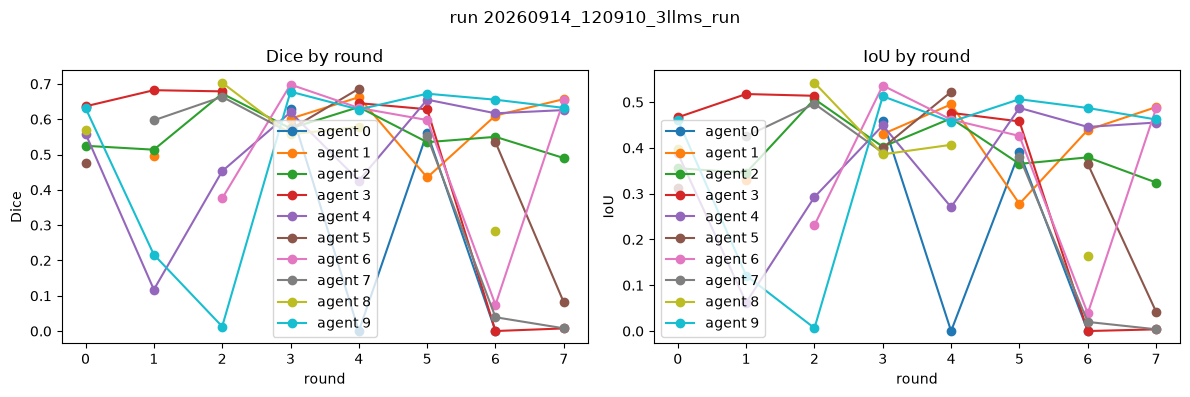

In [8]:
# Dice/IoU progression per agent across rounds (the swarm's optimization trace).
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for agent_idx, group in ledger.sort_values("round").groupby("agent_idx"):
    axes[0].plot(group["round"], group["dice"], marker="o", label=f"agent {agent_idx}")
    axes[1].plot(group["round"], group["iou"], marker="o", label=f"agent {agent_idx}")
for ax, title in zip(axes, ["Dice", "IoU"]):
    ax.set_xlabel("round"); ax.set_ylabel(title); ax.set_title(f"{title} by round"); ax.legend()
fig.suptitle(f"run {RUN_ID}")
fig.tight_layout()
plt.show()

## 3. Load the agent's pipeline and (re)train

Only `pipeline.py` is persisted per agent/round -- the trained model itself is not. This mirrors `driver.py`: load the module, validate the contract, then run `preprocess -> build_model -> train` on the train split.

In [13]:
from typing import Any

def load_pipeline_module(run_id: str, round_idx: int, agent_idx: int):
    path = settings.runs_dir / run_id / f"round_{round_idx}" / f"agent_{agent_idx}" / "pipeline.py"
    assert path.exists(), f"no pipeline.py at {path}"
    spec = importlib.util.spec_from_file_location(f"pipeline_{run_id}_{round_idx}_{agent_idx}", path)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    validate_module(mod)
    return mod


pipeline = load_pipeline_module(RUN_ID, ROUND, AGENT_IDX)
print(f"loaded pipeline.py for run={RUN_ID} round={ROUND} agent={AGENT_IDX}")
print(f"ledger says: dice={round_rows.loc[round_rows.agent_idx == AGENT_IDX, 'dice'].values}")

loaded pipeline.py for run=20260911_173527 round=1 agent=2
ledger says: dice=[0.6892179]


In [14]:
t0 = time.time()
X_train_processed = pipeline.preprocess(X_train)
model = pipeline.build_model(None)
model = pipeline.train(model, X_train_processed, y_train)
print(f"trained in {time.time() - t0:.1f}s")

trained in 290.0s


## 4. Inference on sample tiles

In [19]:
N_SAMPLES = 6
SAMPLE_SEED = 42

rng = np.random.default_rng(SAMPLE_SEED)
sample_idx = rng.choice(len(X_val), size=min(N_SAMPLES, len(X_val)), replace=False)
X_group, y_group = X_val[sample_idx], y_val[sample_idx]
group_ids = [val_ids[i] for i in sample_idx]

preds_group = infer(pipeline, model, X_group)
print(f"ran inference on {len(sample_idx)} val tiles: {group_ids}")

ran inference on 6 val tiles: [469, 522, 308, 642, 312, 58]


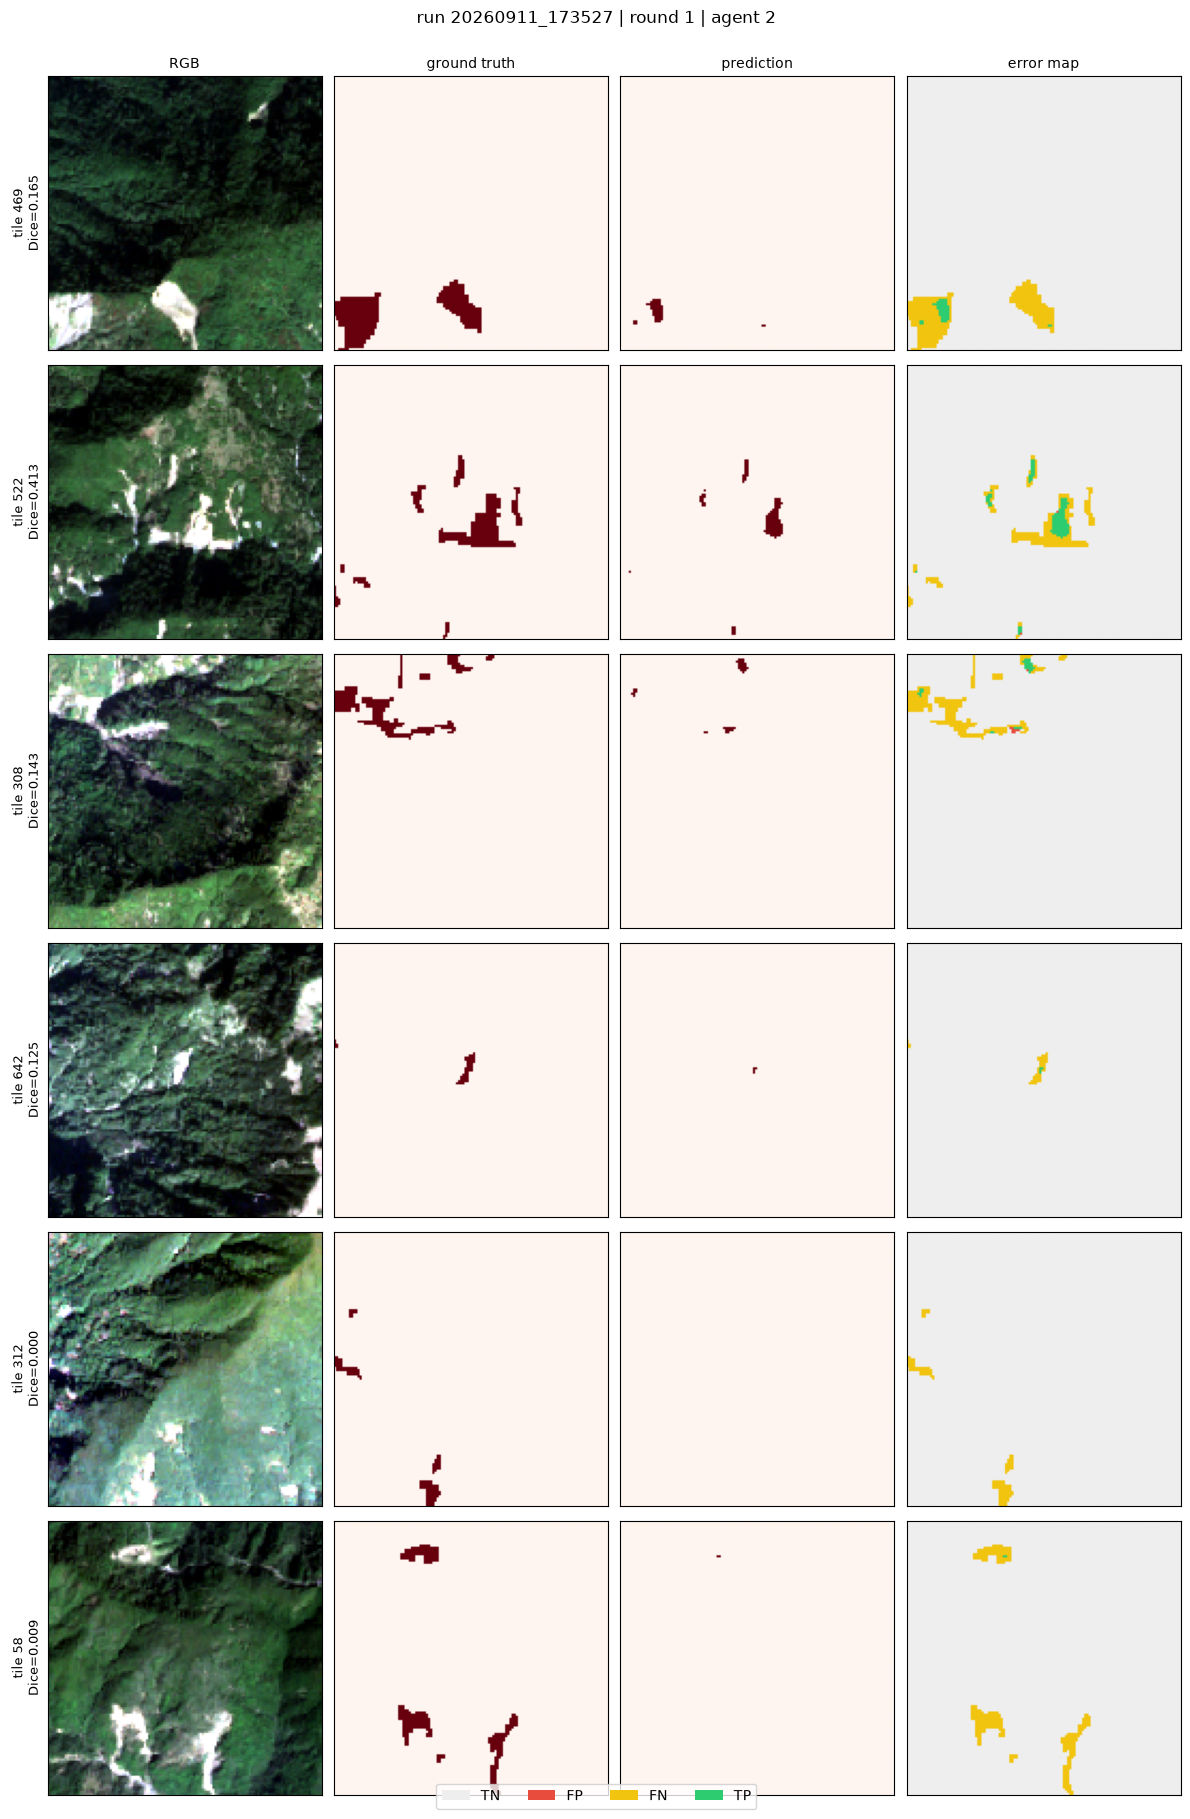

In [20]:
ERROR_CMAP = ListedColormap(["#eeeeee", "#e74c3c", "#f1c40f", "#2ecc71"])  # TN, FP, FN, TP
ERROR_LEGEND = [
    Patch(facecolor="#eeeeee", label="TN"),
    Patch(facecolor="#e74c3c", label="FP"),
    Patch(facecolor="#f1c40f", label="FN"),
    Patch(facecolor="#2ecc71", label="TP"),
]


def error_map(pred: np.ndarray, gt: np.ndarray) -> np.ndarray:
    pred, gt = pred.astype(bool), gt.astype(bool)
    out = np.zeros(pred.shape, dtype=np.uint8)
    out[~pred & gt] = 2   # FN
    out[pred & ~gt] = 1   # FP
    out[pred & gt] = 3    # TP
    return out


def plot_inference_grid(X, y_true, y_pred, ids) -> None:
    n = len(X)
    fig, axes = plt.subplots(n, 4, figsize=(12, 3 * n))
    axes = np.atleast_2d(axes)
    col_titles = ["RGB", "ground truth", "prediction", "error map"]
    for row in range(n):
        tile_dice = dice(y_pred[row], y_true[row])
        panels = [rgb_composite(X[row]), y_true[row], y_pred[row], error_map(y_pred[row], y_true[row])]
        for col, panel in enumerate(panels):
            ax = axes[row, col]
            if col == 3:
                ax.imshow(panel, cmap=ERROR_CMAP, vmin=0, vmax=3)
            elif col in (1, 2):
                ax.imshow(panel, cmap="Reds", vmin=0, vmax=1)
            else:
                ax.imshow(panel)
            ax.set_xticks([]); ax.set_yticks([])
            if row == 0:
                ax.set_title(col_titles[col], fontsize=10)
            if col == 0:
                ax.set_ylabel(f"tile {ids[row]}\nDice={tile_dice:.3f}", fontsize=9)
    fig.legend(handles=ERROR_LEGEND, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.02 / n))
    fig.suptitle(f"run {RUN_ID} | round {ROUND} | agent {AGENT_IDX}", y=1.0)
    fig.tight_layout()
    plt.show()


plot_inference_grid(X_group, y_group, preds_group, group_ids)

## 5. Evaluation

Dice/IoU for the sampled group above, the full val split (matching what `eval/infer.py::evaluate` reports during a run), and per-tile score distribution + an aggregate spatial error map across the group.

In [21]:
group_scores = {"dice": dice(preds_group, y_group), "iou": iou(preds_group, y_group)}
print(f"sampled group ({len(sample_idx)} tiles): {group_scores}")

t0 = time.time()
val_scores = evaluate(pipeline, model, X_val, y_val)
print(f"full val split ({len(X_val)} tiles): {val_scores}  (evaluated in {time.time() - t0:.1f}s)")

sampled group (6 tiles): {'dice': 0.19025522044894608, 'iou': 0.10512820516644751}
full val split (100 tiles): {'dice': 0.39306708160530046, 'iou': 0.24460702566169132}  (evaluated in 6.2s)


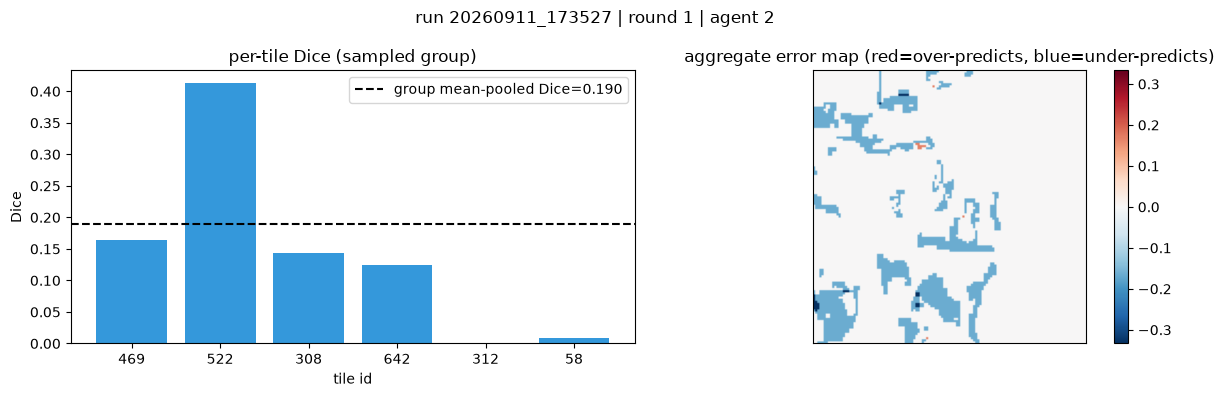

In [22]:
per_tile_dice = np.array([dice(preds_group[i], y_group[i]) for i in range(len(sample_idx))])


def aggregate_error_map(preds: np.ndarray, gt: np.ndarray) -> np.ndarray:
    """Per-pixel (FP frequency - FN frequency) across a group of tiles: >0 over-predicts here, <0 under-predicts."""
    fp_freq = (preds.astype(bool) & ~gt.astype(bool)).mean(axis=0)
    fn_freq = (~preds.astype(bool) & gt.astype(bool)).mean(axis=0)
    return fp_freq - fn_freq


def plot_aggregate_error_map(preds: np.ndarray, gt: np.ndarray, ax, title: str):
    net_error = aggregate_error_map(preds, gt)
    vabs = float(np.abs(net_error).max()) or 1.0
    im = ax.imshow(net_error, cmap="RdBu_r", vmin=-vabs, vmax=vabs)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title)
    return im


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar([str(i) for i in group_ids], per_tile_dice, color="#3498db")
axes[0].axhline(group_scores["dice"], color="black", linestyle="--", label=f"group mean-pooled Dice={group_scores['dice']:.3f}")
axes[0].set_xlabel("tile id"); axes[0].set_ylabel("Dice"); axes[0].set_title("per-tile Dice (sampled group)")
axes[0].legend()

im = plot_aggregate_error_map(preds_group, y_group, axes[1], "aggregate error map (red=over-predicts, blue=under-predicts)")
fig.colorbar(im, ax=axes[1], fraction=0.046)

fig.suptitle(f"run {RUN_ID} | round {ROUND} | agent {AGENT_IDX}")
fig.tight_layout()
plt.show()

## 6. Compare agents within the selected round

Cheap comparison straight from the ledger (no retraining).

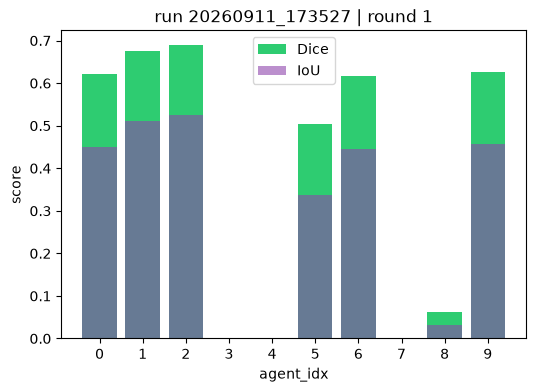

,agent_idx,dice,iou,success,debug_iters,carried_forward
10,0,6.207603e-01,4.500742e-01,True,2,False
11,1,6.764066e-01,5.110381e-01,True,0,False
12,2,6.892179e-01,5.258066e-01,True,0,False
13,3,1.227958e-12,1.227958e-12,True,0,False
14,4,1.227958e-12,1.227958e-12,True,1,False
15,5,5.042866e-01,3.371546e-01,True,0,False
16,6,6.166967e-01,4.458145e-01,True,2,False
17,7,1.227958e-12,1.227958e-12,True,0,False
18,8,6.299025e-02,3.251933e-02,True,0,False
19,9,6.263373e-01,4.559615e-01,True,0,False


In [23]:
fig, ax = plt.subplots(figsize=(6, 4))
plot_rows = round_rows.sort_values("agent_idx")
ax.bar(plot_rows["agent_idx"].astype(str), plot_rows["dice"], color="#2ecc71", label="Dice")
ax.bar(plot_rows["agent_idx"].astype(str), plot_rows["iou"], color="#8e44ad", alpha=0.6, label="IoU")
ax.set_xlabel("agent_idx"); ax.set_ylabel("score"); ax.set_title(f"run {RUN_ID} | round {ROUND}")
ax.legend()
plt.show()

plot_rows[["agent_idx", "dice", "iou", "success", "debug_iters", "carried_forward"]]

## 7. Final check — held-out test split

The test split has not been touched anywhere above: it wasn't used for training (section 3), for picking the visualized sample group (section 4), or for any evaluation number so far (sections 5-6). It's loaded and scored here exactly once, as a final unbiased check of the agent's pipeline + model from section 3.

In [ ]:
MAX_TEST_TILES = settings.max_val_tiles  # same cap as val above for a quick pass; set to None to score the full held-out set

X_test, y_test, test_ids = load_split("test", settings.dataset_dir, MAX_TEST_TILES)
print(f"test: X={X_test.shape} y={y_test.shape}")
pos_frac = y_test.mean()
tiles_with_landslide = (y_test.reshape(len(y_test), -1).sum(axis=1) > 0).mean()
print(f"test: landslide pixels={pos_frac:.3%}, tiles containing landslide={tiles_with_landslide:.1%}")

test: X=(100, 128, 128, 14) y=(100, 128, 128)
test: landslide pixels=2.591%, tiles containing landslide=65.0%


In [ ]:
t0 = time.time()
preds_test = infer(pipeline, model, X_test)
test_scores = {"dice": dice(preds_test, y_test), "iou": iou(preds_test, y_test)}
print(f"inferred {len(X_test)} test tiles in {time.time() - t0:.1f}s")

comparison = pd.DataFrame(
    [group_scores, val_scores, test_scores],
    index=[f"sampled group (n={len(sample_idx)})", f"val split (n={len(X_val)})", f"TEST split (n={len(X_test)}, held-out)"],
)
comparison

inferred 100 test tiles in 3.2s


,dice,iou
sampled group (n=6),0.440919,0.282807
val split (n=100),0.603954,0.432618
"TEST split (n=100, held-out)",0.671570,0.505537


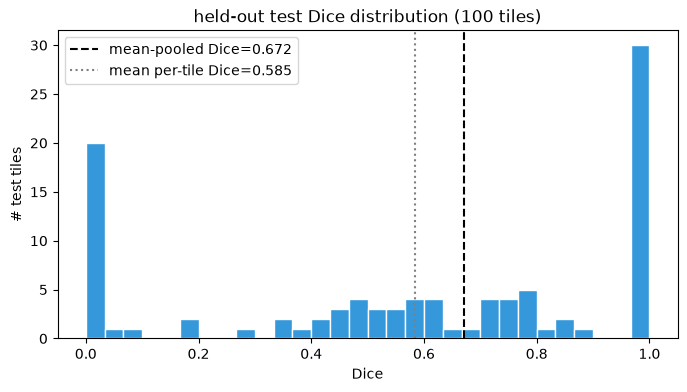

In [ ]:
per_tile_dice_test = np.array([dice(preds_test[i], y_test[i]) for i in range(len(X_test))])

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(per_tile_dice_test, bins=30, color="#3498db", edgecolor="white")
ax.axvline(test_scores["dice"], color="black", linestyle="--", label=f"mean-pooled Dice={test_scores['dice']:.3f}")
ax.axvline(per_tile_dice_test.mean(), color="gray", linestyle=":", label=f"mean per-tile Dice={per_tile_dice_test.mean():.3f}")
ax.set_xlabel("Dice"); ax.set_ylabel("# test tiles")
ax.set_title(f"held-out test Dice distribution ({len(X_test)} tiles)")
ax.legend()
plt.show()

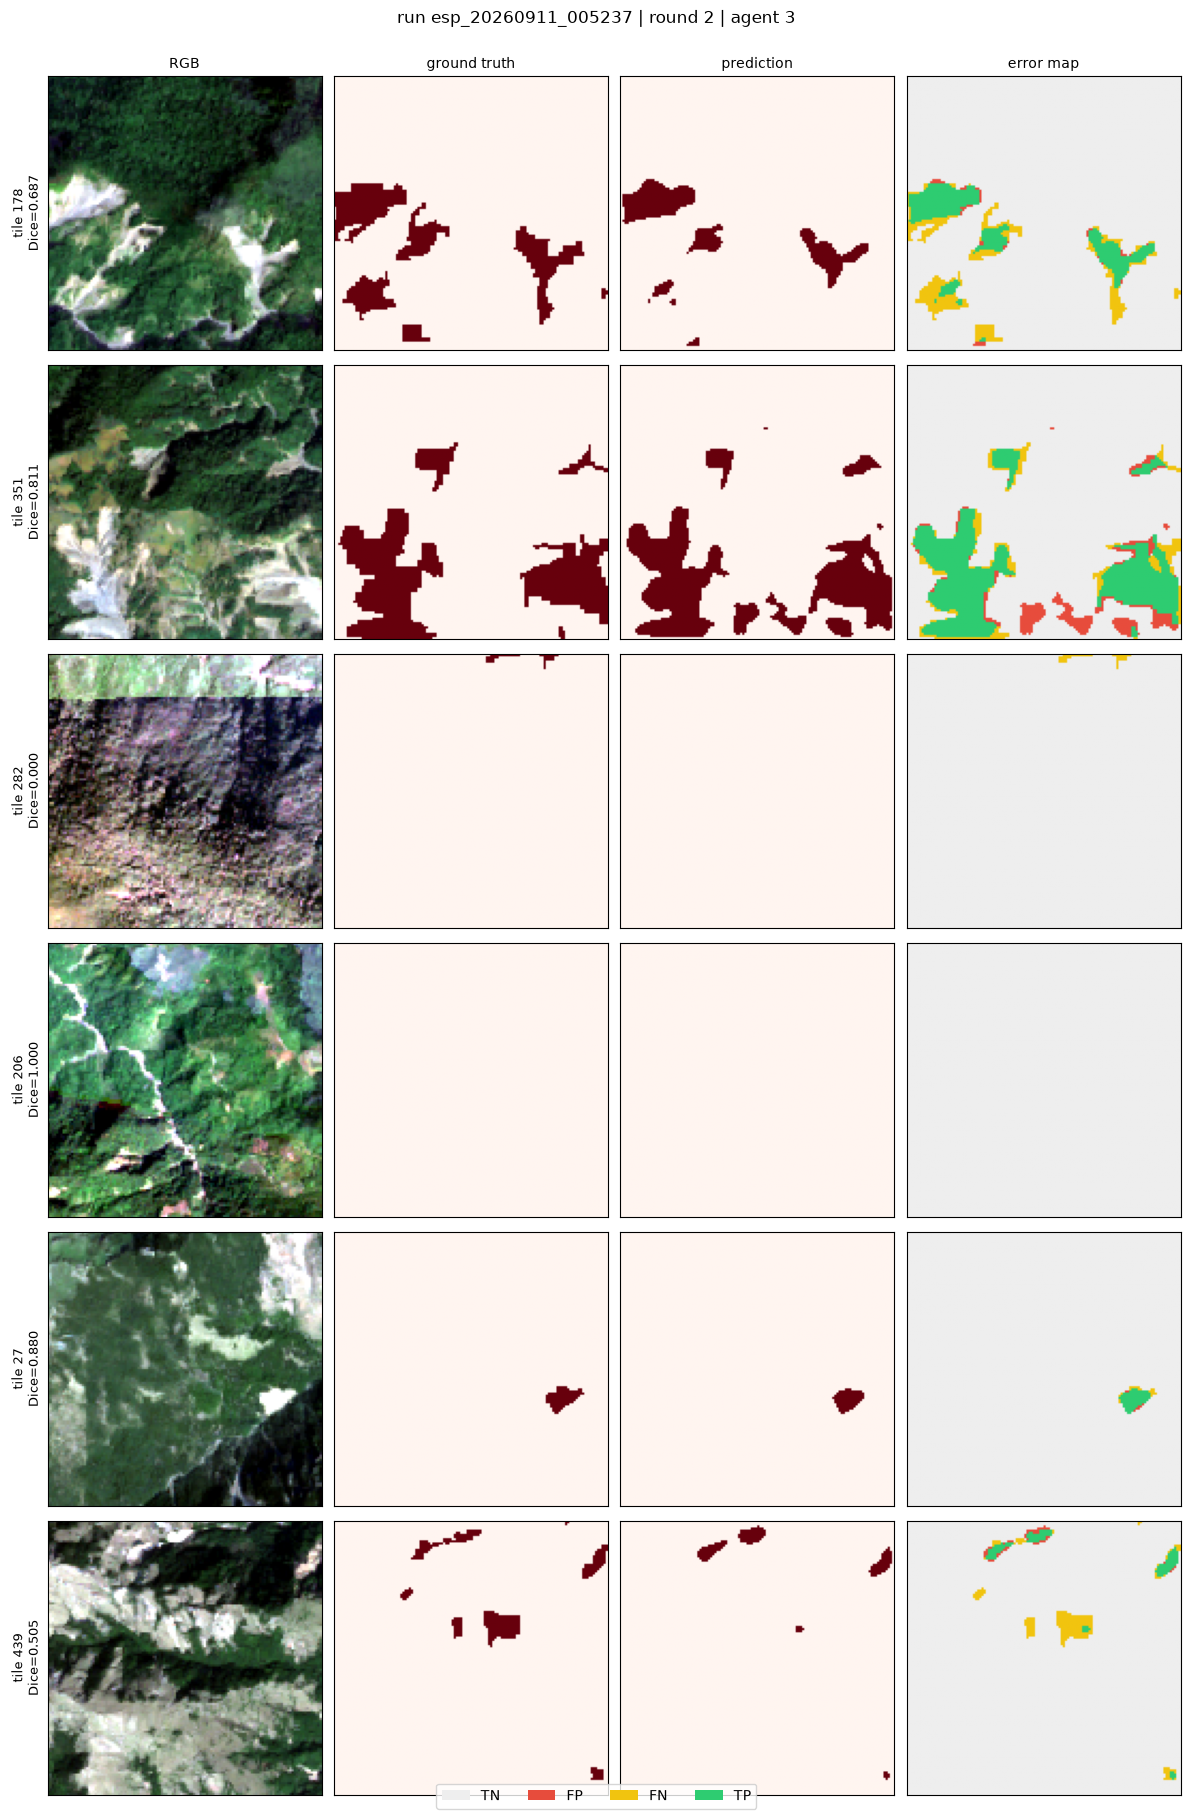

In [ ]:
# sample prediction maps on the held-out test set (same layout as section 4)
test_sample_idx = np.random.default_rng(SAMPLE_SEED).choice(len(X_test), size=min(N_SAMPLES, len(X_test)), replace=False)
plot_inference_grid(
    X_test[test_sample_idx], y_test[test_sample_idx], preds_test[test_sample_idx],
    [test_ids[i] for i in test_sample_idx],
)

## 8. PSO visualization: agents drifting through skill-space

`skill.md` is text, not a numeric position, so there is no literal PSO coordinate to plot. To still show agents "moving" round to round, this section:

1. Embeds every agent's `skill.md` for every round it ran, using the project's own retrieval embedder (`settings.embedding_model`, already a package dependency).
2. Projects all those embeddings for the run into 2D two different ways, fit once on the full pooled set so the space itself stays fixed and only the agents move between frames:
   - PCA -- linear, deterministic, a stable baseline.
   - UMAP -- nonlinear, tends to preserve local neighborhoods better
3. Animates both projections side by side, one frame per round: marker size encodes that round's Dice, a fading trail shows each agent's path, and a gold star marks whichever agent currently holds the swarm's best Dice so far.

Caveats carried over from the brainstorm: treat the 2D layout as illustrative, not quantitative -- with a few dozen points, distances mostly reflect the dominant axes of wording variation, not a rigorous semantic distance. The "best Dice so far" trace is also a simplification of AgentPSO's real global-best rule: it is the running max Dice across agents per round, ignoring the p_best_epsilon improvement margin the actual algorithm uses (exact personal-best precedence is not reconstructable from summary.json alone).

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import matplotlib.animation as animation
from IPython.display import HTML

try:
    import umap
except ImportError as exc:
    raise ImportError(
        "this section needs `umap-learn` (notebook-only, not a package dependency): "
        "run `uv add --group notebook umap-learn`"
    ) from exc


def collect_skill_history(run_id: str) -> pd.DataFrame:
    """One row per (round, agent) that ran: its skill.md text + that round's Dice."""
    path = settings.runs_dir / run_id / "summary.json"
    summary = json.loads(path.read_text(encoding="utf-8"))
    per_agent_history = summary["per_agent_history"]
    rows = []
    for agent_idx_str, hist in per_agent_history.items():
        agent_idx = int(agent_idx_str)
        for r in hist["rounds"]:
            skill_path = settings.runs_dir / run_id / f"round_{r['round']}" / f"agent_{agent_idx}" / "skill.md"
            rows.append({
                "round": r["round"],
                "agent_idx": agent_idx,
                "dice": r["dice"] if r["dice"] is not None else np.nan,
                "skill_md": skill_path.read_text(encoding="utf-8") if skill_path.exists() else "",
            })
    return pd.DataFrame(rows).sort_values(["round", "agent_idx"]).reset_index(drop=True)


skill_history = collect_skill_history(RUN_ID)
print(f"{len(skill_history)} (round, agent) skill.md snapshots for run {RUN_ID}")
skill_history[["round", "agent_idx", "dice"]]

d:\Flávio Rocha USER\OneDrive\University of Twente\MSc 2025-2027\Y2Q1 Agentic and Multi Agent Systems\AutoLSM-Swarm\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



80 (round, agent) skill.md snapshots for run 20260914_120910_3llms_run


,round,agent_idx,dice
0,0,0,0.635289
1,0,1,NaN
2,0,2,0.524708
3,0,3,0.636457
4,0,4,0.559305
...,...,...,...
75,7,5,0.081202
76,7,6,0.654401
77,7,7,0.007842
78,7,8,NaN


In [10]:
t0 = time.time()
embedder = SentenceTransformer(settings.embedding_model)
embeddings = embedder.encode(skill_history["skill_md"].tolist(), show_progress_bar=False)
print(f"embedded {embeddings.shape} skill.md texts in {time.time() - t0:.1f}s")

embedded (80, 384) skill.md texts in 15.3s


In [ ]:
pca_coords = PCA(n_components=2, random_state=0).fit_transform(embeddings)

n_points = len(embeddings)
if n_points >= 4:
    n_neighbors = max(2, min(15, n_points - 1))
    umap_coords = umap.UMAP(n_components=2, n_neighbors=n_neighbors, random_state=0).fit_transform(embeddings)
else:
    print(f"only {n_points} snapshots -- too few for a meaningful UMAP fit, reusing PCA coords for that panel")
    umap_coords = pca_coords.copy()

# umap_coords.shape # (80,2)
skill_history["pca_x"], skill_history["pca_y"] = pca_coords[:, 0], pca_coords[:, 1]
skill_history["umap_x"], skill_history["umap_y"] = umap_coords[:, 0], umap_coords[:, 1]

d:\Flávio Rocha USER\OneDrive\University of Twente\MSc 2025-2027\Y2Q1 Agentic and Multi Agent Systems\AutoLSM-Swarm\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [15]:
umap_coords.shape

(80, 2)

In [ ]:
# Approximate the swarm's "best Dice so far" and which agent holds it, round by round
# (running max across agents; see the p_best_epsilon caveat above).
agents_sorted = sorted(skill_history["agent_idx"].unique())
rounds_sorted = sorted(skill_history["round"].unique())

best_so_far = -np.inf
leader_agent = None
leader_trace, gbest_trace, round_leader_trace = {}, {}, {}
for r in rounds_sorted:
    round_rows = skill_history[skill_history["round"] == r]
    row_max = round_rows["dice"].max()
    if pd.notna(row_max) and row_max > best_so_far:
        best_so_far = row_max
        leader_agent = int(round_rows.loc[round_rows["dice"].idxmax(), "agent_idx"])
    gbest_trace[r] = best_so_far
    leader_trace[r] = leader_agent
    # This round's own best agent, independent of the cumulative best-so-far above.
    round_leader_trace[r] = (
        int(round_rows.loc[round_rows["dice"].idxmax(), "agent_idx"]) if pd.notna(row_max) else None
    )

In [ ]:
AGENT_COLORS = plt.cm.tab10(np.linspace(0, 1, max(len(agents_sorted), 1)))
agent_color = {a: AGENT_COLORS[i] for i, a in enumerate(agents_sorted)}


def dice_to_size(d: float) -> float:
    if pd.isna(d):
        return 40.0
    return 80.0 + 400.0 * max(0.0, min(1.0, d))


fig, (ax_pca, ax_umap) = plt.subplots(1, 2, figsize=(13, 6))
panels = ((ax_pca, "pca_x", "pca_y"), (ax_umap, "umap_x", "umap_y"))
for ax, title in zip((ax_pca, ax_umap), ("PCA", "UMAP")):
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
for ax, xcol, ycol in panels:
    pad_x = 0.1 * ((skill_history[xcol].max() - skill_history[xcol].min()) or 1)
    pad_y = 0.1 * ((skill_history[ycol].max() - skill_history[ycol].min()) or 1)
    ax.set_xlim(skill_history[xcol].min() - pad_x, skill_history[xcol].max() + pad_x)
    ax.set_ylim(skill_history[ycol].min() - pad_y, skill_history[ycol].max() + pad_y)

scatters, trails, leader_markers, round_leader_markers = {}, {}, {}, {}
for ax, xcol, ycol in panels:
    scatters[ax] = ax.scatter([], [], s=[], c=[], edgecolors="black", linewidths=0.6, zorder=3)
    trails[ax] = {
        a: ax.plot([], [], "-", color=agent_color[a], alpha=0.4, linewidth=1.5, zorder=1)[0]
        for a in agents_sorted
    }
    leader_markers[ax] = ax.scatter([], [], marker="*", s=500, c="gold", edgecolors="black", linewidths=1, zorder=4)
    round_leader_markers[ax] = ax.scatter([], [], marker="*", s=250, c="red", edgecolors="black", linewidths=1, zorder=5)

title_text = fig.suptitle("")


def update(frame_idx: int):
    r = rounds_sorted[frame_idx]
    up_to = skill_history[skill_history["round"] <= r]
    current = skill_history[skill_history["round"] == r]
    for ax, xcol, ycol in panels:
        pts = current[[xcol, ycol]].values
        scatters[ax].set_offsets(pts if len(pts) else np.empty((0, 2)))
        scatters[ax].set_color([agent_color[a] for a in current["agent_idx"]])
        scatters[ax].set_sizes([dice_to_size(d) for d in current["dice"]])
        for a in agents_sorted:
            hist = up_to[up_to["agent_idx"] == a].sort_values("round")
            trails[ax][a].set_data(hist[xcol], hist[ycol])
        leader_row = current[current["agent_idx"] == leader_trace[r]]
        if len(leader_row):
            leader_markers[ax].set_offsets(leader_row[[xcol, ycol]].values)

        round_leader_row = current[current["agent_idx"] == round_leader_trace[r]]
        if len(round_leader_row):
            round_leader_markers[ax].set_offsets(round_leader_row[[xcol, ycol]].values)
    title_text.set_text(
        f"run {RUN_ID} | round {r}/{rounds_sorted[-1]} | best Dice so far: {gbest_trace[r]:.4f} (agent {leader_trace[r]})"
    )
    return []


handles = [
    plt.Line2D([0], [0], marker="o", linestyle="", color=agent_color[a], label=f"agent {a}")
    for a in agents_sorted
] + [
    plt.Line2D([0], [0], marker="*", linestyle="", markersize=14, markerfacecolor="gold",
               markeredgecolor="black", label="best Dice so far"),
    plt.Line2D([0], [0], marker="*", linestyle="", markersize=9, markerfacecolor="red",
               markeredgecolor="black", label="this round's best"),
]
fig.legend(handles=handles, loc="lower center", ncol=min(len(agents_sorted), 8))

anim = animation.FuncAnimation(fig, update, frames=len(rounds_sorted), interval=900, blit=False, repeat=True)
plt.close(fig)
HTML(anim.to_jshtml())

# X - Extra Tests

In [3]:
from corpus.retrieve import format_for_prompt, retrieve_diverse
from config import Settings
from agents.prompts import RETRIEVAL_QUERY

settings = Settings()
agent_docs = retrieve_diverse(RETRIEVAL_QUERY, settings, settings.n_agents)

d:\Flávio Rocha USER\OneDrive\University of Twente\MSc 2025-2027\Y2Q1 Agentic and Multi Agent Systems\AutoLSM-Swarm\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [31]:
prompt = format_for_prompt(agent_docs[0], settings)

In [36]:
with open('file.txt', 'w', encoding='utf-8') as f:
    f.write(prompt)

# prompt